## Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df=pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.shape

(545, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
cat_cols=df.dtypes[df.dtypes=="object"].index
cat_cols

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [19]:
lb = LabelEncoder()

In [20]:
for col in cat_cols:
    df[col] = lb.fit_transform(df[col])

In [21]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad            int64
guestroom           int64
basement            int64
hotwaterheating     int64
airconditioning     int64
parking             int64
prefarea            int64
furnishingstatus    int64
dtype: object

### Heatmap for correlation and multicolinearity check

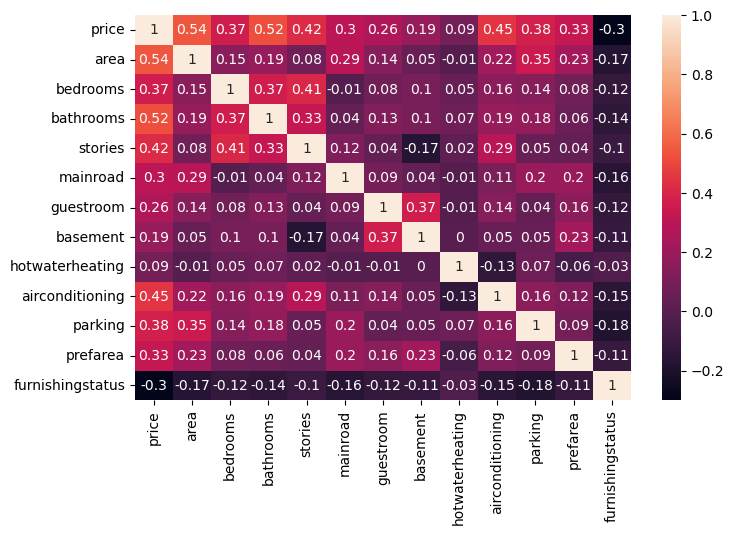

In [30]:
corr=df.corr().round(2)
plt.figure(figsize=(8,5))
sns.heatmap(corr,annot=True)
plt.rc('ytick', labelsize=15)
plt.show()

### Data Labelling

In [31]:
x=df.drop("price",axis=1)
y=df["price"]
print(x.shape)
print(y.shape)

(545, 12)
(545,)


### Splitting the data into training and testing

In [32]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)
                                    
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(408, 12)
(137, 12)
(408,)
(137,)


### Model building on training

In [33]:
m1 = LinearRegression()
m1.fit(x_train,y_train)

LinearRegression()

### Model Evaluation on training and testing data both

In [34]:
# Model score - R2_Score
print('Training Score',m1.score(x_train,y_train))
print('Testing Score',m1.score(x_test,y_test))

Training Score 0.6839176617755487
Testing Score 0.6614628548582819


In [41]:
# Predict
y_pred = m1.predict(x_test)

In [43]:
y_pred_train = m1.predict(x_train)

In [47]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R² Score for testing data: {r2:.2f}")
r2_train = r2_score(y_train, y_pred_train)
print(f"R² Score for training data: {r2_train:.2f}")

R² Score for testing data: 0.66
R² Score for training data: 0.68


In [36]:
x_test.shape

(137, 12)

In [48]:
x_train.shape

(408, 12)

In [35]:
n = x_test.shape[0] #No. of rows
p = x_test.shape[1] #No. of columns

In [50]:
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"Adjusted R² for testing: {adjusted_r2:.2f}")

Adjusted R² for testing: 0.65


In [53]:
n2 = x_train.shape[0] #No. of rows
p2 = x_train.shape[1] #No. of columns

In [54]:
adjusted_r2_train = 1 - (1 - r2_train) * (n2 - 1) / (n2 - p2 - 1)
print(f"Adjusted R² for training: {adjusted_r2_train:.2f}")

Adjusted R² for training: 0.67
